In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Data loading 

In [ ]:
data_path = 'data\data.csv'

In [5]:
raw_df = pd.read_csv(data_path)
raw_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


# Data overview 

In [49]:
def show_data_overview(df):
    print('\nSample data (first 5 rows): ')
    display(df.head(5))
    print("-"*50)
    print('\nInformation:')
    print(df.info())
    print("-"*50)
    print('\nThe number of duplicated rows:')
    print(df.duplicated().sum())
    print("-"*50)
    print('\nThe number of mising data per feature:')
    display(df.isna().sum().sort_values(ascending = False))
    

In [ ]:
show_data_overview(raw_df)

# Splitting train/val/test data 

In [6]:
X = raw_df.drop(columns=['is_promoted']).copy()
y = raw_df['is_promoted'].copy()

In [7]:
from sklearn.model_selection import train_test_split 
def split_train_val_test(X,y,val_size = 0.15, test_size=0.15,random_state=42,stratify = True):
    X_train_val,X_test,y_train_val,y_test = train_test_split(
                                            X,y,test_size = test_size,
                                            random_state = random_state,
                                            stratify = y if stratify else None)
    relative_val_size = val_size/(1-test_size)
    X_train,X_val,y_train,y_val = train_test_split(
                                X_train_val,y_train_val,
                                test_size = relative_val_size,
                                random_state = random_state, 
                                stratify = y_train_val if stratify else None)
    print(f'Train set: {len(X_train)} samples')
    print(f'Val set: {len(X_val)} samples')
    print(f'Test set: {len(X_test)} samples')
    return X_train,X_val,X_test,y_train,y_val,y_test


In [8]:
random_state = 42
val_size = 0.15
test_size =0.15
stratify = True 
X_train, X_val,X_test,y_train,y_val,y_test = split_train_val_test(
                                            X,y,val_size= val_size, test_size = test_size,
                                            random_state = random_state,
                                            stratify = stratify)


Train set: 38364 samples
Val set: 8222 samples
Test set: 8222 samples


# EDA train set 

In [50]:
train_df = pd.concat([X_train,y_train],axis = 1)
eda_df = train_df.copy()
show_data_overview(eda_df)


Sample data (first 5 rows): 


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
1491,5714,Sales & Marketing,region_13,Bachelor's,m,other,2,32,2.0,3,0,50,0
11424,45205,Procurement,region_31,Bachelor's,f,other,2,28,2.0,4,0,65,0
190,11645,Sales & Marketing,region_23,Master's & above,m,other,1,41,5.0,7,0,51,0
13545,31464,Operations,region_5,Bachelor's,m,other,1,43,5.0,12,0,61,0
5730,26630,Operations,region_2,Bachelor's,m,other,1,43,3.0,7,0,60,0


--------------------------------------------------

Information:
<class 'pandas.core.frame.DataFrame'>
Index: 38364 entries, 1491 to 7542
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           38364 non-null  int64  
 1   department            38364 non-null  object 
 2   region                38364 non-null  object 
 3   education             36684 non-null  object 
 4   gender                38364 non-null  object 
 5   recruitment_channel   38364 non-null  object 
 6   no_of_trainings       38364 non-null  int64  
 7   age                   38364 non-null  int64  
 8   previous_year_rating  35435 non-null  float64
 9   length_of_service     38364 non-null  int64  
 10  awards_won?           38364 non-null  int64  
 11  avg_training_score    38364 non-null  int64  
 12  is_promoted           38364 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 4.1+ MB
No

previous_year_rating    2929
education               1680
employee_id                0
region                     0
department                 0
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [51]:
target = 'is_promoted'
num_features = eda_df.select_dtypes(include=['number']).columns.tolist()
num_features.remove(target)
num_features.remove('awards_won?')
cat_features = eda_df.select_dtypes(include=['object']).columns.tolist()
cat_features.append('awards_won?')
print("Numeric features: ",num_features)
print("Categorical features: ",cat_features)
print("Target: ", target)

Numeric features:  ['employee_id', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'avg_training_score']
Categorical features:  ['department', 'region', 'education', 'gender', 'recruitment_channel', 'awards_won?']
Target:  is_promoted


## Missing data 

In [ ]:
def analyze_missing_data(df):
    summary = pd.DataFrame({
        'count': df.isna().sum(),
        'percentage(%)': (df.isna().mean() * 100).round(2)
    })
    missing_df = summary[summary['count'] > 0].sort_values(by='count', ascending=False)
    missing_cols = missing_df.index.tolist()
    
    print("Missing data summary:")
    print("-" * 50)
    print(missing_df)
    print("-" * 50)
    
    
    
    
    if len(missing_cols) >= 2: 
        
        intersect_mask = df[missing_cols].isna().all(axis=1)
        intersect_count = intersect_mask.sum()
        intersect_percent = (intersect_count / len(df) * 100).round(2) 

        any_mask = df[missing_cols].isna().any(axis=1)
        any_count = any_mask.sum()
        any_percent = (any_count / len(df) * 100).round(2)
        
        print(f"Intersection (missing in ALL): {intersect_count} ({intersect_percent}%)")
        print(f"Union (missing in ANY):        {any_count} ({any_percent}%)")
        print("-" * 50)
    return missing_cols 

In [ ]:
missing_features = analyze_missing_data(eda_df)

### previous_year_rating 

In [ ]:
eda_df[eda_df['previous_year_rating'].isna()]

In [ ]:
len(eda_df[(eda_df['previous_year_rating'].isna()) & (eda_df['length_of_service']!=1)])

In [ ]:
len(eda_df[ (eda_df['previous_year_rating']==0.0)])

Cột : previous_year_rating 
- Missing value là do đây là các nhân sự mới làm năm đầu tiên nên không có điểm đánh giá từ năm trước
- Cột này cũng không tồn tại các bạn nào có rating = 0
- Quyết định: fillna = 0 cho các  bạn này

### education

In [ ]:
eda_df[eda_df['education'].isna()]

Cột education:
- Không tìm thấy mối quan hệ với các cột trong datasets để có thể lắp lại 
- Chiếm một lượng nhỏ trong toàn tập train: khoảng 4% - sẽ drop khi phân tích EDA 
- Dùng imputer : most_frequent hoặc unknown khi làm pipeline cho model 

### Xử lí 

In [ ]:
eda_df['previous_year_rating'] = eda_df['previous_year_rating'].fillna(0)

eda_df = eda_df.dropna(subset=['education'])

In [ ]:
analyze_missing_data(eda_df)

## Target 

In [ ]:
target_summary = pd.DataFrame({
    'count':eda_df[target].value_counts(),
    'percent%':(eda_df[target].value_counts(normalize= True)*100).round(2)
})
print(target_summary)

## Numeric data 

In [ ]:
print(num_features)

Cột employee_id chủ yếu đóng vai trò làm định danh cho sample, không có giá trị thống kê
-> drop employee_id 

In [ ]:
num_features.remove('employee_id')
print(num_features)


In [42]:
def analyze_numeric_features(df,num_features):
    print(f"There are {len(num_features)} features: {num_features}" )
    print("-"*50)
    for feature in num_features:
        print(f'\nFeature: {feature}')
        
        print(f"\nStatistics:")
        print(df[feature].describe())
        
        print(f"\nVisualization:")
        fig,ax = plt.subplots(1,2,figsize=(10,5))
        sns.histplot(data = df,x = feature, kde = True, ax = ax[0])
        ax[0].set_title(f'Distribution of {feature}')
        sns.boxplot(data=df, x = feature,ax = ax[1])
        ax[1].set_title(f'Boxplot of {feature}')
        plt.tight_layout()
        plt.show()
        print("-"*50)
    

In [ ]:
analyze_numeric_features(eda_df, num_features)

In [43]:
def analyze_num_vs_target(df,num_features,target):
    for feature in num_features:
        print(f'\nFeature: {feature} vs {target}')
        fig,ax = plt.subplots(1,2,figsize=(10,5))
        sns.boxplot(data=df, x= target, y = feature, ax=ax[0])
        sns.kdeplot(data=df, x= feature, hue= target, 
                    fill= True, common_norm= False, ax = ax[1])
        plt.tight_layout()
        plt.show()


In [ ]:
analyze_num_vs_target(eda_df,num_features,target = target)

## Categorical data 

In [ ]:
print(cat_features)

In [44]:
def analyze_categorical_features(df,cat_features):
    print(f"There are {len(cat_features)} features: {cat_features}" )
    print("-"*50)
    for feature in cat_features:
        print(f'\nFeature: {feature}')
        print(f"Statistics:")
        summary = df[feature].value_counts().to_frame('Count')
        summary['Percentage'] = (df[feature].value_counts(normalize = True)*100).round(2)
        print(summary)
        print(f"Visualization:")
        plt.figure(figsize = (10,6))
        if len(summary.index) < 10 :
            sns.countplot(data=df, x= feature, order = summary.index)
        else: 
            sns.countplot(data=df, y= feature, order = summary.index)
        plt.tight_layout()
        plt.show()
    

In [ ]:
analyze_categorical_features(eda_df,cat_features)

In [45]:
def analyze_cat_vs_target(df,cat_features,target):
    for feature in cat_features:
        print(f'\nFeature: {feature} vs {target}')
        summary = df.groupby(feature)[target].mean().sort_values(ascending=False).to_frame('target_rate')
        summary['target_rate'] = (summary['target_rate']*100).round(2)
        fig,ax = plt.subplots(1,2,figsize=(15,6))
        sns.countplot(data=df, y = feature, hue = target, ax= ax[0], order= summary.index)
        sns.barplot(data=df, y= feature, x= target, ax= ax[1],order= summary.index)
        plt.tight_layout()
        plt.show()
        print("-"*50)

        

In [ ]:
analyze_cat_vs_target(eda_df, cat_features, target)

## Feature engineering 

In [ ]:
dept_mean = eda_df.groupby('department')['avg_training_score'].transform('mean')
eda_df['relative_training_score'] = eda_df['avg_training_score'] / dept_mean

In [ ]:
eda_df['joining_age'] = eda_df['age'] - eda_df['length_of_service']

In [ ]:
eda_df['total_training_score'] = eda_df['no_of_trainings'] * eda_df['avg_training_score']

In [ ]:
derived_features = ['relative_training_score','joining_age','total_training_score']
analyze_numeric_features(eda_df,derived_features)

In [ ]:
analyze_num_vs_target(eda_df, derived_features, target)

## Hypothese testing 

In [ ]:

from scipy.stats import chi2_contingency, ttest_ind 

In [ ]:
def test_categorical_significance(df, cat_features, target):
    results = []
    for col in cat_features:

        contingency_table = pd.crosstab(df[col], df[target])
        
        # Chi-Square Testing 
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
        
        results.append({
            'Feature': col,
            'P-value': p_value,
            'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
        })
        
    summary_df = pd.DataFrame(results).sort_values(by='P-value').reset_index(drop=True)
    
    return summary_df

In [ ]:


def test_numerical_significance(df, num_features, target):
    results = []
    
    for col in num_features:
    
        group_0 = df[df[target] == 0][col]
        group_1 = df[df[target] == 1][col]
        

        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)
   
        results.append({
            'Feature': col,
            'P-value': p_value,
            'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
        })
   
    summary_df = pd.DataFrame(results).sort_values(by='P-value').reset_index(drop=True)
    
    return summary_df

In [ ]:
num_features = num_features+derived_features
test_numerical_significance(eda_df, num_features,target)

In [ ]:
test_categorical_significance(eda_df, cat_features, target)

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

def calculate_cramers_v(df, cat_features, target):
    results = []
    for col in cat_features:
        clean_df = df[[col, target]].dropna()
        crosstab = pd.crosstab(clean_df[col], clean_df[target])
        
        chi2 = chi2_contingency(crosstab)[0]
        n = crosstab.sum().sum()
        
        v_score = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
        
        results.append({
            'Feature': col, 
            'Cramers_V_Score': round(v_score, 4)
        })
        
    return pd.DataFrame(results).sort_values(by='Cramers_V_Score', ascending=False).reset_index(drop=True)

In [ ]:
calculate_cramers_v(eda_df, cat_features, target)

- Droping : gender,age, employee_id 
- One-hot encoding : department, recruitment_channel
- Mapping: education
- Imputer : education (most_frequent), previous_year(0)
- Feature engineering : relative_training_score, total_training_score
- Region : target encoding / group 3 

In [ ]:
eda_df.info()

# Data Preprocessing 

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, FunctionTransformer
import category_encoders as ce
from sklearn.base import BaseEstimator, TransformerMixin

In [10]:
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col='department', target_col='avg_training_score', new_col_name='relative_training_score'):
        self.group_col = group_col
        self.target_col = target_col
        self.new_col_name = new_col_name
        self.group_means_ = {}

    def fit(self, X, y=None):
        self.group_means_ = X.groupby(self.group_col)[self.target_col].mean().to_dict()
        return self

    def transform(self, X):
        X_new = X.copy()
        
        X_new['total_training_score'] = X_new['no_of_trainings'] * X_new['avg_training_score']

        dept_mean = X_new[self.group_col].map(self.group_means_).fillna(X_new[self.target_col].mean())
        X_new[self.new_col_name] = X_new[self.target_col] / (dept_mean + 1e-5)
        
        return X_new
    def set_output(self, transform=None):
        return self
        
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_ + ['total_training_score', self.new_col_name]



In [11]:
drop_cols = ['employee_id', 'gender', 'age']
onehot_cols = ['department', 'recruitment_channel']
ordinal_cols = ['education']
target_encode_cols = ['region']
constant_impute_cols = ['previous_year_rating']
numeric_cols = [
    'no_of_trainings', 'length_of_service', 'avg_training_score', 
     'total_training_score', 'relative_training_score'
]
passthrough_cols = ['awards_won?']



In [12]:

num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', RobustScaler())
])

ord_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['Below Secondary', "Bachelor's", "Master's & above"]],
        handle_unknown='use_encoded_value', 
        unknown_value=-1                    
    ))
])


ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

te_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('target', ce.TargetEncoder())
])


rating_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='constant', fill_value=0))
])



In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('drop', 'drop', drop_cols),
        ('num', num_pipeline, numeric_cols),
        ('ord', ord_pipeline, ordinal_cols),
        ('ohe', ohe_pipeline, onehot_cols),
        ('te', te_pipeline, target_encode_cols),
        ('rating', rating_pipeline, constant_impute_cols),
        ('pass', 'passthrough', passthrough_cols) 
    ],
    remainder='drop' 
)


preprocessing_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineeringTransformer()),
    ('preprocessing', preprocessor)
])
preprocessing_pipeline.set_output(transform="pandas")

Pipeline(steps=[('feature_engineering', FeatureEngineeringTransformer()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('drop', 'drop',
                                                  ['employee_id', 'gender',
                                                   'age']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['no_of_trainings',
                                                   'length_of_service',
                                                   'avg_training_score',
                                                   'total_training_score',
                                                   'rela...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['department',
                                                   'recruitment_channel']),
                                                 ('te',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['region']),
                                                 ('rating',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['previous_year_rating']),
                                                 ('pass', 'passthrough',
                                                  ['awards_won?'])]))])

In [ ]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
print("Kích thước ma trận sau xử lý:", X_train_processed.shape)
display(X_train_processed.head(5))

In [ ]:
# đã học từ tập train mà không bị rò rỉ dữ liệu (data leakage).
X_val_processed = preprocessing_pipeline.transform(X_val)
print("Kích thước ma trận sau xử lý:", X_val_processed.shape)
display(X_val_processed.head(5))

In [ ]:
X_test_processed = preprocessing_pipeline.transform(X_test)
print("Kích thước ma trận sau xử lý:", X_test_processed.shape)
display(X_test_processed.head(5))

# Modeling 

## Baseline model

### Lazypredict 

In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

In [ ]:
X_train_lazy,X_test_lazy,y_train_lazy,y_test_lazy = train_test_split(
                                            X_train,y_train,test_size = test_size,
                                            random_state = random_state,
                                            stratify = y_train if stratify else None)
X_train_lazy = preprocessing_pipeline.fit_transform(X_train_lazy,y_train_lazy)
X_test_lazy = preprocessing_pipeline.transform(X_test_lazy)

In [ ]:

clf = LazyClassifier(
    verbose=0, 
    ignore_warnings=True, 
    custom_metric=None, 
    predictions=True
)

models, predictions = clf.fit(X_train_lazy,X_test_lazy,y_train_lazy,y_test_lazy)

display(models.sort_values(by = 'ROC AUC', ascending = False).head(15))
display(models.sort_values(by = 'ROC AUC').head(15))

### Classical Models

In [14]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, 
    f1_score, precision_recall_fscore_support, average_precision_score
)

# Nhóm Traditional
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Nhóm Ensemble
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [ ]:
def run_benchmark_traditional(X, y, preprocessing_pipeline, cv_splits=5, random_state=42):
    
    models = {
        "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=random_state),
        "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=random_state),
        "Gaussian Naive Bayes": GaussianNB(),
        "K-Neighbors": KNeighborsClassifier(),
        "SVM": SVC(class_weight='balanced', probability=True, random_state=random_state)
    }

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    results = []

    for name, base_model in models.items():
        acc_list, bal_acc_list, roc_list, prauc_list, f1_macro_list = [], [], [], [], []
        p0_list, r0_list, f1_0_list = [], [], []
        p1_list, r1_list, f1_1_list = [], [], []

        for train_idx, val_idx in cv.split(X, y):
            if hasattr(X, "iloc"):
                X_tr_f, X_va_f = X.iloc[train_idx], X.iloc[val_idx]
                y_tr_f, y_va_f = y.iloc[train_idx], y.iloc[val_idx]
            else:
                X_tr_f, X_va_f = X[train_idx], X[val_idx]
                y_tr_f, y_va_f = y[train_idx], y[val_idx]

            fold_pipeline = clone(preprocessing_pipeline)
            X_tr_processed = fold_pipeline.fit_transform(X_tr_f, y_tr_f)
            X_va_processed = fold_pipeline.transform(X_va_f)

            model = clone(base_model)
            model.fit(X_tr_processed, y_tr_f)
            
            y_pred = model.predict(X_va_processed)
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_va_processed)[:, 1]
            else:
                y_prob = model.decision_function(X_va_processed)

            acc_list.append(accuracy_score(y_va_f, y_pred))
            bal_acc_list.append(balanced_accuracy_score(y_va_f, y_pred))
            roc_list.append(roc_auc_score(y_va_f, y_prob))
            prauc_list.append(average_precision_score(y_va_f, y_prob))
            f1_macro_list.append(f1_score(y_va_f, y_pred, average='macro'))

            precision_arr, recall_arr, f1_arr, _ = precision_recall_fscore_support(
                y_va_f, y_pred, average=None, zero_division=0
            )
            
            p0_list.append(precision_arr[0])
            r0_list.append(recall_arr[0])
            f1_0_list.append(f1_arr[0])

            p1_list.append(precision_arr[1])
            r1_list.append(recall_arr[1])
            f1_1_list.append(f1_arr[1])

        results.append({
            "Model": name,
            "Accuracy": np.mean(acc_list),
            "Balanced Accuracy": np.mean(bal_acc_list),
            "ROC AUC": np.mean(roc_list),
            "PR AUC": np.mean(prauc_list),
            "F1 Macro": np.mean(f1_macro_list),
            "Precision (Class 0)": np.mean(p0_list),
            "Recall (Class 0)": np.mean(r0_list),
            "F1 (Class 0)": np.mean(f1_0_list),
            "Precision (Class 1)": np.mean(p1_list),
            "Recall (Class 1)": np.mean(r1_list),
            "F1 (Class 1)": np.mean(f1_1_list)
        })

    return pd.DataFrame(results).sort_values(by="PR AUC", ascending=False).reset_index(drop=True)




   

In [ ]:
def run_benchmark_ensembles(X, y, preprocessing_pipeline, cv_splits=5, random_state=42):
    
    neg_count = np.sum(y == 0)
    pos_count = np.sum(y == 1)
    scale_weight = neg_count / pos_count if pos_count > 0 else 1.0

    models = {
        "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=random_state, n_jobs=-1),
        "Extra Trees": ExtraTreesClassifier(class_weight='balanced', random_state=random_state, n_jobs=-1),
        "AdaBoost": AdaBoostClassifier(random_state=random_state),
        "XGBoost": XGBClassifier(scale_pos_weight=scale_weight, random_state=random_state, eval_metric='logloss', n_jobs=-1),
        "LightGBM": LGBMClassifier(scale_pos_weight=scale_weight, random_state=random_state, verbose=-1, n_jobs=-1),
        "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', random_state=random_state, verbose=0)
    }

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    results = []

    for name, base_model in models.items():
        acc_list, bal_acc_list, roc_list, prauc_list, f1_macro_list = [], [], [], [], []
        p0_list, r0_list, f1_0_list = [], [], []
        p1_list, r1_list, f1_1_list = [], [], []

        for train_idx, val_idx in cv.split(X, y):
            if hasattr(X, "iloc"):
                X_tr_f, X_va_f = X.iloc[train_idx], X.iloc[val_idx]
                y_tr_f, y_va_f = y.iloc[train_idx], y.iloc[val_idx]
            else:
                X_tr_f, X_va_f = X[train_idx], X[val_idx]
                y_tr_f, y_va_f = y[train_idx], y[val_idx]

            fold_pipeline = clone(preprocessing_pipeline)
            X_tr_processed = fold_pipeline.fit_transform(X_tr_f, y_tr_f)
            X_va_processed = fold_pipeline.transform(X_va_f)

            model = clone(base_model)
            model.fit(X_tr_processed, y_tr_f)
            
            y_pred = model.predict(X_va_processed)
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_va_processed)[:, 1]
            else:
                y_prob = model.decision_function(X_va_processed)

            acc_list.append(accuracy_score(y_va_f, y_pred))
            bal_acc_list.append(balanced_accuracy_score(y_va_f, y_pred))
            roc_list.append(roc_auc_score(y_va_f, y_prob))
            prauc_list.append(average_precision_score(y_va_f, y_prob))
            f1_macro_list.append(f1_score(y_va_f, y_pred, average='macro'))

            precision_arr, recall_arr, f1_arr, _ = precision_recall_fscore_support(
                y_va_f, y_pred, average=None, zero_division=0
            )
            
            p0_list.append(precision_arr[0])
            r0_list.append(recall_arr[0])
            f1_0_list.append(f1_arr[0])

            p1_list.append(precision_arr[1])
            r1_list.append(recall_arr[1])
            f1_1_list.append(f1_arr[1])

        results.append({
            "Model": name,
            "Accuracy": np.mean(acc_list),
            "Balanced Accuracy": np.mean(bal_acc_list),
            "ROC AUC": np.mean(roc_list),
            "PR AUC": np.mean(prauc_list),
            "F1 Macro": np.mean(f1_macro_list),
            "Precision (Class 0)": np.mean(p0_list),
            "Recall (Class 0)": np.mean(r0_list),
            "F1 (Class 0)": np.mean(f1_0_list),
            "Precision (Class 1)": np.mean(p1_list),
            "Recall (Class 1)": np.mean(r1_list),
            "F1 (Class 1)": np.mean(f1_1_list)
        })

    return pd.DataFrame(results).sort_values(by="PR AUC", ascending=False).reset_index(drop=True)

In [ ]:
cv_splits = 5

In [ ]:
run_benchmark_traditional(X_train, y_train, preprocessing_pipeline, cv_splits=5, random_state=random_state)

In [ ]:
run_benchmark_ensembles(X_train, y_train, preprocessing_pipeline, cv_splits=cv_splits, random_state=random_state)

## Fine-tuning model 

In [ ]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, 
    f1_score, precision_recall_fscore_support, average_precision_score
)

def evaluate_model(y_true, y_pred, y_prob):
  
    precision_arr, recall_arr, f1_arr, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    return {
    
        "PR_AUC": average_precision_score(y_true, y_prob), 
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "F1_Macro": f1_score(y_true, y_pred, average='macro'),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        
 
        "precision_class_0": precision_arr[0],
        "recall_class_0": recall_arr[0],
        "f1_class_0": f1_arr[0],
        
        "precision_class_1": precision_arr[1],
        "recall_class_1": recall_arr[1],
        "f1_class_1": f1_arr[1]
    }

In [ ]:
import optuna
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

def objective_lgbm(trial, X, y, preprocessing_pipeline, scale_weight, random_state=42, cv_splits=5):
    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        'scale_pos_weight': scale_weight, 
        'random_state': random_state,
        'verbose': -1,
        'n_jobs': -1
    }

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
 
    pr_auc_scores = []
    f1_macro_scores = []
    precision_cls1_scores = []
    recall_cls1_scores = []

    for train_idx, val_idx in cv.split(X, y):
        if hasattr(X, "iloc"):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        else:
            X_tr, X_va = X[train_idx], X[val_idx]
            y_tr, y_va = y[train_idx], y[val_idx]

        fold_pipeline = clone(preprocessing_pipeline)
        X_tr_proc = fold_pipeline.fit_transform(X_tr, y_tr)
        X_va_proc = fold_pipeline.transform(X_va)

        model = LGBMClassifier(**param_grid)
        model.fit(X_tr_proc, y_tr)

        y_pred = model.predict(X_va_proc)
        y_prob = model.predict_proba(X_va_proc)[:, 1]


        metrics = evaluate_model(y_va, y_pred, y_prob)
        
        pr_auc_scores.append(metrics["PR_AUC"])
        f1_macro_scores.append(metrics["F1_Macro"])
        precision_cls1_scores.append(metrics["precision_class_1"])
        recall_cls1_scores.append(metrics["recall_class_1"])

   
    trial.set_user_attr("F1_Macro", np.mean(f1_macro_scores))
    trial.set_user_attr("precision_class_1", np.mean(precision_cls1_scores))
    trial.set_user_attr("recall_class_1", np.mean(recall_cls1_scores))

    return np.mean(pr_auc_scores)

In [18]:
num_class_0 = np.sum(y_train == 0)
num_class_1 = np.sum(y_train == 1)
scale_weight = num_class_0 / num_class_1

In [ ]:
import warnings
warnings.filterwarnings("ignore") 

func = lambda trial: objective_lgbm(
    trial, X_train, y_train, 
    preprocessing_pipeline, 
    scale_weight=scale_weight 
)

study = optuna.create_study(direction="maximize", study_name="LGBM")
print("Fine-tuning LightGBM...")
study.optimize(func, n_trials=100, show_progress_bar=True)

print("\nBest parameters:")
print(study.best_params)
print(f"PR-AUCt: {study.best_value:.4f}")
print(study.best_trial.number)     
print(study.best_trial.value)      
print(study.best_trial.params)     
print(study.best_trial.user_attrs) 

In [ ]:
def objective_adaboost(trial, X, y, preprocessing_pipeline, random_state=42, cv_splits=5):

    max_depth = trial.suggest_int('base_max_depth', 1, 3)
    
    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'estimator': DecisionTreeClassifier(max_depth=max_depth, random_state=random_state),
        'random_state': random_state
    }

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    pr_auc_scores = []
    f1_macro_scores = []
    precision_cls1_scores = []
    recall_cls1_scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        
        fold_pipeline = clone(preprocessing_pipeline)
        X_tr_proc = fold_pipeline.fit_transform(X_tr, y_tr)
        X_va_proc = fold_pipeline.transform(X_va)

     
        model = AdaBoostClassifier(**param_grid)
        model.fit(X_tr_proc, y_tr)

        y_pred = model.predict(X_va_proc)
        y_prob = model.predict_proba(X_va_proc)[:, 1]

        metrics = evaluate_model(y_va, y_pred, y_prob)
        
        pr_auc_scores.append(metrics["PR_AUC"])
        f1_macro_scores.append(metrics["F1_Macro"])
        precision_cls1_scores.append(metrics["precision_class_1"])
        recall_cls1_scores.append(metrics["recall_class_1"])

    trial.set_user_attr("F1_Macro", np.mean(f1_macro_scores))
    trial.set_user_attr("precision_class_1", np.mean(precision_cls1_scores))
    trial.set_user_attr("recall_class_1", np.mean(recall_cls1_scores))

    return np.mean(pr_auc_scores)

In [ ]:
func_ada = lambda trial: objective_adaboost(trial, X_train, y_train, preprocessing_pipeline)
study_ada = optuna.create_study(direction="maximize", study_name="AdaBoost")

print("Fine-tuning AdaBoost...")
study_ada.optimize(func_ada, n_trials=100, show_progress_bar=True)

print("\nBest parameters:")
print(study_ada.best_params)
print(f"PR-AUC: {study_ada.best_value:.4f}")
print(f"Trial: {study_ada.best_trial.number}")
print(f"F1, Precision, Recall: {study_ada.best_trial.user_attrs}")

## Training Model and Validation test 

In [15]:
from sklearn.metrics import classification_report, average_precision_score
from sklearn.pipeline import Pipeline

In [16]:
def build_and_train_pipeline(classifier, preprocessor, X_tr, y_tr):
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    model_name = classifier.__class__.__name__
    print(f"Traing model: {model_name}: ")
    
    pipeline.fit(X_tr, y_tr)
    return pipeline


def evaluate_model_performance(fitted_pipeline, X_tr, y_tr, X_va, y_va, name="Model"):
    y_tr_prob = fitted_pipeline.predict_proba(X_tr)[:, 1]
    y_va_prob = fitted_pipeline.predict_proba(X_va)[:, 1]
    y_va_pred = fitted_pipeline.predict(X_va)
   
    pr_auc_tr = average_precision_score(y_tr, y_tr_prob)
    pr_auc_va = average_precision_score(y_va, y_va_prob)
    
    print(f"================ {name} ================")
    print(f"PR-AUC Train: {pr_auc_tr:.4f} | Validation: {pr_auc_va:.4f}")
    print("\n--- Classification Report ---")
    print(classification_report(y_va, y_va_pred, zero_division=0))
    print("="*50 + "\n")



In [ ]:
# LightGBM
best_lgbm_params = study.best_params.copy()
best_lgbm_params['random_state'] = random_state
best_lgbm_params['verbose'] = -1
best_lgbm_params['scale_pos_weight'] = scale_weight
clf_lgbm = LGBMClassifier(**best_lgbm_params)

# AdaBoost
best_ada_params = study_ada.best_params.copy()
max_depth_ada = best_ada_params.pop('base_max_depth', 3)

clf_adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=max_depth_ada, random_state=random_state),
    **best_ada_params,
    random_state=random_state
)


In [20]:

pipe_lgbm = build_and_train_pipeline(clf_lgbm, preprocessing_pipeline, X_train, y_train)
pipe_ada  = build_and_train_pipeline(clf_adaboost, preprocessing_pipeline, X_train, y_train)

evaluate_model_performance(pipe_lgbm, X_train, y_train, X_val, y_val, name="LightGBM")
evaluate_model_performance(pipe_ada, X_train, y_train, X_val, y_val, name="AdaBoost")


Traing model: LGBMClassifier: 
Traing model: AdaBoostClassifier: 
================ LightGBM ================
PR-AUC Train: 0.5717 | Validation: 0.5479

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      7522
           1       0.27      0.63      0.38       700

    accuracy                           0.82      8222
   macro avg       0.61      0.73      0.64      8222
weighted avg       0.90      0.82      0.85      8222


================ AdaBoost ================
PR-AUC Train: 0.5583 | Validation: 0.5351

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      7522
           1       0.92      0.34      0.50       700

    accuracy                           0.94      8222
   macro avg       0.93      0.67      0.74      8222
weighted avg       0.94      0.94      0.93      8222




## Soft voting 

Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 
Traing model: VotingClassifier: 


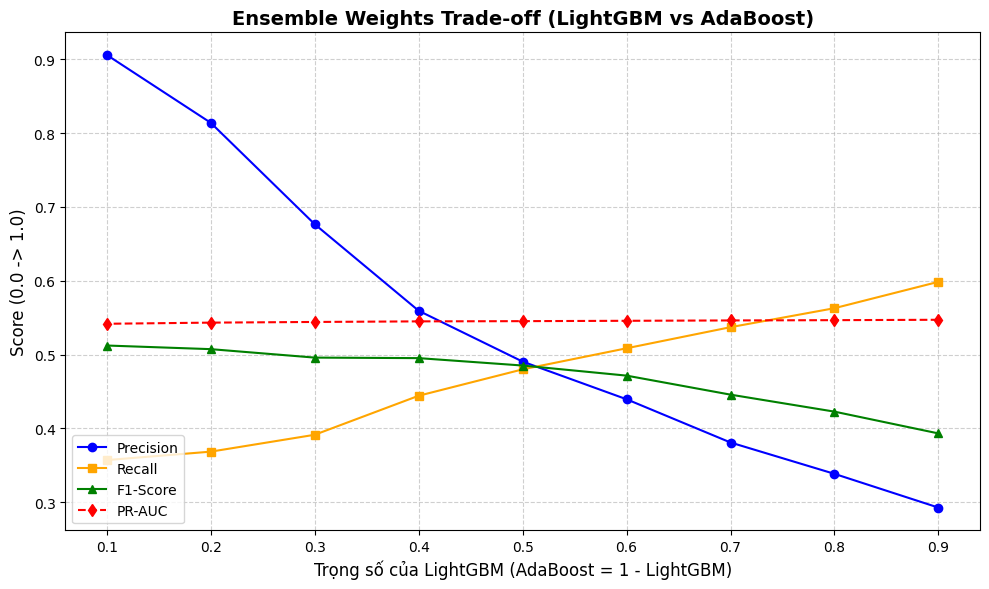

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.ensemble import VotingClassifier

weights_to_test = [
    [0.9, 0.1], [0.8, 0.2], [0.7, 0.3], 
    [0.6, 0.4], [0.5, 0.5], [0.4, 0.6], 
    [0.3, 0.7], [0.2, 0.8], [0.1, 0.9]
]

lgbm_weights_list = []
precisions = []
recalls = []
f1_scores = []
pr_aucs = []

for w in weights_to_test:
    
    clf_voting = VotingClassifier(
        estimators=[
            ('lgbm', clf_lgbm), 
            ('adaboost', clf_adaboost)
        ],
        voting='soft',
        weights=w 
    )

    current_pipe_ens = build_and_train_pipeline(clf_voting, preprocessing_pipeline, X_train, y_train)
    
  
    y_val_pred = current_pipe_ens.predict(X_val)
    y_val_proba = current_pipe_ens.predict_proba(X_val)[:, 1]
    
    
    lgbm_weights_list.append(w[0]) 
    precisions.append(precision_score(y_val, y_val_pred))
    recalls.append(recall_score(y_val, y_val_pred))
    f1_scores.append(f1_score(y_val, y_val_pred))
    pr_aucs.append(average_precision_score(y_val, y_val_proba))


plt.figure(figsize=(10, 6))

plt.plot(lgbm_weights_list, precisions, marker='o', color='blue', label='Precision')
plt.plot(lgbm_weights_list, recalls, marker='s', color='orange', label='Recall')
plt.plot(lgbm_weights_list, f1_scores, marker='^', color='green', label='F1-Score')
plt.plot(lgbm_weights_list, pr_aucs, marker='d', color='red', linestyle='--', label='PR-AUC')

plt.title('Ensemble Weights Trade-off (LightGBM vs AdaBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số của LightGBM (AdaBoost = 1 - LightGBM)', fontsize=12)
plt.ylabel('Score (0.0 -> 1.0)', fontsize=12)
plt.xticks(lgbm_weights_list)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

## Threshold Cabliration 

In [31]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score


prob_lgbm = pipe_lgbm.predict_proba(X_val)[:, 1]
prob_ada  = pipe_ada.predict_proba(X_val)[:, 1]

prob_soft = (0.6 * prob_lgbm) + (0.4 * prob_ada)

thresholds = np.arange(0.5, 0.95, 0.05)

def print_calibration_table(y_true, y_prob, model_name):
    print(f"\n{model_name}")
    print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Is Promoted'}")
    print("-" * 75)
    
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        
        p = precision_score(y_true, y_pred_t, zero_division=0)
        r = recall_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)
        promoted_count = np.sum(y_pred_t)
        
        print(f"> {t:<8.2f} | {p:<10.4f} | {r:<10.4f} | {f1:<10.4f} | {promoted_count}")
    print("-" * 75)

print_calibration_table(y_val, prob_ada, "ADABOOST")
print_calibration_table(y_val, prob_soft, "SOFT VOTING [0.1 LightGBM - 0.9 AdaBoost]")


ADABOOST
Threshold  | Precision  | Recall     | F1-Score   | Is Promoted
---------------------------------------------------------------------------
> 0.50     | 0.9234     | 0.3443     | 0.5016     | 261
> 0.55     | 0.9582     | 0.3271     | 0.4878     | 239
> 0.60     | 0.9738     | 0.3186     | 0.4801     | 229
> 0.65     | 0.9864     | 0.3114     | 0.4734     | 221
> 0.70     | 0.9860     | 0.3029     | 0.4634     | 215
> 0.75     | 0.9846     | 0.2743     | 0.4291     | 195
> 0.80     | 0.9836     | 0.2571     | 0.4077     | 183
> 0.85     | 0.9812     | 0.2243     | 0.3651     | 160
> 0.90     | 0.0000     | 0.0000     | 0.0000     | 0
---------------------------------------------------------------------------

SOFT VOTING [0.1 LightGBM - 0.9 AdaBoost]
Threshold  | Precision  | Recall     | F1-Score   | Is Promoted
---------------------------------------------------------------------------
> 0.50     | 0.4395     | 0.5086     | 0.4715     | 810
> 0.55     | 0.5363     | 0.4543 

## Result on test set 

In [32]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np

clf_final = VotingClassifier(
    estimators=[('lgbm', clf_lgbm), ('adaboost', clf_adaboost)],
    voting='soft',
    weights=[0.6, 0.4]
)


final_pipeline = build_and_train_pipeline(clf_final, preprocessing_pipeline, X_train, y_train)

print("\nEvaluation on the test set (UNSEEN DATA)")

y_test_prob = final_pipeline.predict_proba(X_test)[:, 1]

# Áp dụng ngưỡng Threshold 0.70
THRESHOLD = 0.70
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

# Tính toán các chỉ số
p_test = precision_score(y_test, y_test_pred, zero_division=0)
r_test = recall_score(y_test, y_test_pred, zero_division=0)
f1_test = f1_score(y_test, y_test_pred, zero_division=0)
promoted_test_count = np.sum(y_test_pred)

print(f"================ Summary (THRESHOLD = {THRESHOLD}) ================")
print(f"Precision  : {p_test:.4f}")
print(f"Recall     : {r_test:.4f}")
print(f"F1-Score   : {f1_test:.4f}")
print(f"Count      : {promoted_test_count} người\n")

print(classification_report(y_test, y_test_pred, zero_division=0))

Traing model: VotingClassifier: 

Evaluation on the test set (UNSEEN DATA)
================ Summary (THRESHOLD = 0.7) ================
Precision  : 0.9288
Recall     : 0.3543
F1-Score   : 0.5129
Count      : 267 người

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      7522
           1       0.93      0.35      0.51       700

    accuracy                           0.94      8222
   macro avg       0.94      0.68      0.74      8222
weighted avg       0.94      0.94      0.93      8222



In [33]:
import joblib

joblib.dump(final_pipeline, 'hr_promotion_pipeline.pkl')

print("Save file: hr_promotion_pipeline.pkl")

Save file: hr_promotion_pipeline.pkl


In [34]:
from IPython.display import FileLink
FileLink('hr_promotion_pipeline.pkl')

/kaggle/working/hr_promotion_pipeline.pkl